$$\Large\boxed{\text{AME 5202 Deep Learning, Even Semester 2026}}$$

$$\large\text{Theme}: \underline{\text{building a softmax classifier from scratch using efficient computations in PyTorch}}$$

---

Load libraries

---

In [1]:
## Load libraries
import numpy as np
import sys
import matplotlib.pyplot as plt
plt.style.use('dark_background')
%matplotlib inline
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix

---

The **MNIST (Modified National Institute of Standards and Technology) dataset** is one of the most widely used benchmark datasets in machine learning and computer vision.

It contains:

- **70,000 grayscale images**
- **28 × 28 pixels** per image
- **10 classes (digits 0–9)**
- Split into **60,000 training** and **10,000 test** images

Each image shows a centered handwritten digit as in the example below:

![mnist](https://1drv.ms/i/c/37720f927b6ddc34/IQQ6UqroXhRjSp1y9MW00bT_AR8-ENNoQV9lkr8uUoFpf7Q)

We will load the MNIST dataset and transform the images (normalize pixel values from 0-1 and flatten) using PyTorch.


---

In [2]:
# Define PyTorch transformation pipeline for the MNIST dataset
transform = transforms.Compose([
    # Converts [28x28] gradyscale image → [1,28,28] tensor normalized to [0, 1]
    transforms.ToTensor(),
    # Flatten to [784]
    transforms.Lambda(lambda x: torch.flatten(x))
])

# Load train dataset
train_dataset = datasets.MNIST(
    root = './data',
    train = True,
    download = True,
    transform = transform
)

# Load test dataset
test_dataset = datasets.MNIST(
    root = './data',
    train = False,
    download = True,
    transform = transform
)

num_samples = len(train_dataset), len(test_dataset)
num_features = train_dataset[0][0].shape[0]
num_labels = torch.unique(train_dataset.targets).numel()

print('MNIST set')
print('---------------------')
print(f'Number of training samples = {num_samples[0]}, test samples = {num_samples[1]}')
print(f'Number of features = {num_features}')
print(f'Number of output labels = {num_labels}')


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.93MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.29MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.11MB/s]

MNIST set
---------------------
Number of training samples = 60000, test samples = 10000
Number of features = 784
Number of output labels = 10


---

A generic layer class with forward and backward methods

----

In [3]:
class Layer():
  def __init__(self):
    self.input = None
    self.output = None

  def forward(self, input):
    raise NotImplementedError("Forward propagation not implemented")

  def backward(self, output_gradient, learning_rate):
    raise NotImplementedError("Backward propagation not implemented")

---

Categorical crossentropy (CCE) loss and its gradient for the batch samples.

---

In [18]:
## Define the loss function and its gradient
class CategoricalCrossEntropyLoss:
  def __init__(self, num_labels):
    self.num_labels = num_labels
    self.Y_onehot = None

  def forward(self, Y, Yhat):
    self.Y_onehot = F.one_hot(Y, num_classes = self.num_labels).float()
    return torch.mean(-torch.log(torch.sum(self.Y_onehot * Yhat, dim = -1)))

  def backward(self, Y, Yhat):
    return -self.Y_onehot/Yhat

---

Softmax activation layer class


---

In [19]:
## Softmax activation layer class
class Softmax(Layer):
  def __init__(self):
    super(Softmax, self).__init__()

  def forward(self, input):
    self.input = input
    # Calculate softmax(input)
    self.output = F.softmax(self.input, dim = -1)
    return self.output

  def backward(self, output_gradient, learning_gradient = None):
    I = torch.eye(self.output.shape[1])
    softmax_local_gradient = (I - self.output.unsqueeze(-1)) * self.output.unsqueeze(-2)
    # Calculate gradient flowing back on the input side of the softmax layer
    input_gradient = torch.einsum('ij,ijk->ik', output_gradient, softmax_local_gradient)
    return input_gradient

---

Dense layer class

---

In [29]:
## Dense layer class
class Dense(Layer):
  def __init__(self, input_size, output_size):
    super(Dense, self).__init__()
    self.weights = torch.randn(input_size, output_size, requires_grad = True) * 0.01

  def forward(self, input):
    self.input = input
    self.output= self.input @ self.weights
    return self.output

  def backward(self, output_gradient, learning_rate = 1e-02):
    # Calculate local gradient w.r.t. weights
    weights_gradient = (1/output_gradient.shape[0]) * (torch.einsum('ij,ik->jk', self.input, output_gradient))
    # Update weights for dense layer
    with torch.no_grad():
      self.weights.data += learning_rate * (-weights_gradient)

---

Neural network class for multilbel classification (loss function is categorical crossentropy and last layer is softmax-activated).


---

In [32]:
class NeuralNetwork:
  def __init__(self, num_features, num_labels, loss_fn, learning_rate = 1e-02):
    self.num_features = num_features
    self.num_labels = num_labels
    self.loss_fn = loss_fn
    self.learning_rate = learning_rate
    # Architecture
    self.layers = [
        Dense(self.num_features, self.num_labels),
        Softmax()
        ]

  # Forward propagation
  def forward(self, x):
    for layer in self.layers:
      x = layer.forward(x)
    return x

  # Backward propagation
  def backward(self, gradient):
    for layer in reversed(self.layers):
      gradient = layer.backward(gradient, self.learning_rate)

---

Train a neural network for multilabel classification.


---

In [33]:
# Initialize model and optimizer
learning_rate = 1e-02
nepochs = 10
batch_size = 32

# Choose appropriate loss function
loss_fn = CategoricalCrossEntropyLoss(num_labels)

# Data loader for batch processing
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False)

model = NeuralNetwork(num_features, num_labels, loss_fn, learning_rate)

# Create empty list to store training and test losses over each epoch
train_loss = [None]*nepochs
test_loss = [None]*nepochs

for epoch in range(nepochs):
  loss = 0.0

  for x_batch, y_batch in train_loader:
    # Forward pass
    predictions = model.forward(x_batch)
    loss = loss + model.loss_fn.forward(y_batch, predictions)

    # Backward pass
    loss_gradient = model.loss_fn.backward(y_batch, predictions)
    model.backward(loss_gradient)

  train_loss[epoch] = loss.detach().numpy() / len(train_loader)

  # Test loss calculation
  loss = 0.0

  with torch.no_grad():
    for x_batch, y_batch in test_loader:
      predictions = model.forward(x_batch)
      loss = loss + model.loss_fn.forward(y_batch, predictions)

  test_loss[epoch] = loss.detach().numpy() / len(test_loader)

  print(f"Epoch {epoch + 1}/{nepochs}, Train Loss: {train_loss[epoch]:.4f}, Test Loss: {test_loss[epoch]:.4f}")

Epoch 1/10, Train Loss: 0.7705, Test Loss: 0.4790
Epoch 2/10, Train Loss: 0.4561, Test Loss: 0.4003
Epoch 3/10, Train Loss: 0.4047, Test Loss: 0.3686
Epoch 4/10, Train Loss: 0.3792, Test Loss: 0.3504
Epoch 5/10, Train Loss: 0.3631, Test Loss: 0.3385
Epoch 6/10, Train Loss: 0.3517, Test Loss: 0.3296
Epoch 7/10, Train Loss: 0.3431, Test Loss: 0.3227
Epoch 8/10, Train Loss: 0.3362, Test Loss: 0.3183
Epoch 9/10, Train Loss: 0.3306, Test Loss: 0.3137
Epoch 10/10, Train Loss: 0.3260, Test Loss: 0.3095


---

Plot training and test loss vs. epoch

---

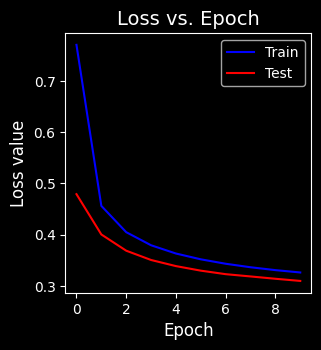

In [34]:
## Plot train and test loss as a function of epoch:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
fig.tight_layout(pad = 4.0)
ax.plot(train_loss, 'b', label = 'Train')
ax.plot(test_loss, 'r', label = 'Test')
ax.set_xlabel('Epoch', fontsize = 12)
ax.set_ylabel('Loss value', fontsize = 12)
ax.legend()
ax.set_title('Loss vs. Epoch', fontsize = 14);

---

Assess model performance on test data

---

In [41]:
all_preds = []
all_true = []

with torch.no_grad():
  for x_batch, y_batch in test_loader:
    outputs = model.forward(x_batch)
    preds = torch.argmax(outputs, dim = 1)
    all_preds.append(preds)
    all_true.append(y_batch)

ypred = torch.cat(all_preds)
ytrue = torch.cat(all_true)

accuracy = (ypred == ytrue).float().mean() * 100
print(f'Accuracy on test data = {accuracy:3.2f}')

print(f'Confusion matrix:\n{confusion_matrix(ytrue.cpu(), ypred.cpu())}')


Accuracy on test data = 91.48
Confusion matrix:
[[ 958    0    2    2    1    4    9    1    3    0]
 [   0 1107    2    3    1    2    4    1   15    0]
 [   7    5  913   16   14    1   13   15   41    7]
 [   3    0   23  910    0   27    3   11   22   11]
 [   1    3    5    1  916    0   10    2    8   36]
 [  10    4    7   41   11  743   14    9   44    9]
 [  10    3    5    2   12   11  912    1    2    0]
 [   2   12   25    7    8    0    0  936    3   35]
 [   6   10   10   24    9   21   13   13  857   11]
 [  11    7    4   12   43    8    0   21    7  896]]


---

Plot a random test sample with its predicted label printed above the plot.

---

Image classified correctly as 3


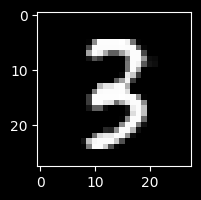

In [96]:
## Plot a random test sample with its predicted label printed above the plot
test_index = np.random.choice(len(test_dataset))
fig, ax = plt.subplots(1, 1, figsize = (2, 2))
print(
    f"Image {'classified correctly' if ypred[test_index] == ytrue[test_index] else 'classified incorrectly'} "
    f"as {ypred[test_index]}"
)
ax.imshow(test_dataset[test_index][0].detach().numpy().reshape(28, 28), cmap = 'gray');